In [ ]:
1. Introduction
This project analyzes how Bitcoin market sentiment (Fear/Greed) impacts trader behavior and performance on Hyperliquid.

In [8]:
from google.colab import files
uploaded = files.upload()


Saving sentiment.csv to sentiment.csv
Saving trader_data.csv to trader_data.csv


In [9]:
import pandas as pd

sentiment = pd.read_csv("sentiment.csv")
trader = pd.read_csv("trader_data.csv")

print(sentiment.head())
print(trader.head())


    timestamp  value classification        date
0  1517463000     30           Fear  01-02-2018
1  1517549400     15   Extreme Fear  02-02-2018
2  1517635800     40           Fear  03-02-2018
3  1517722200     24   Extreme Fear  04-02-2018
4  1517808600     11   Extreme Fear  05-02-2018
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [10]:
print("\nMissing Values - Sentiment Dataset:")
print(sentiment.isnull().sum())

print("\nMissing Values - Trader Dataset:")
print(trader.isnull().sum())



Missing Values - Sentiment Dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing Values - Trader Dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [11]:
print("\nDuplicate Rows in Sentiment Dataset:", sentiment.duplicated().sum())
print("Duplicate Rows in Trader Dataset:", trader.duplicated().sum())



Duplicate Rows in Sentiment Dataset: 0
Duplicate Rows in Trader Dataset: 0


In [12]:
import pandas as pd

# Convert to datetime properly
sentiment['Date'] = pd.to_datetime(sentiment['date'], errors='coerce')
trader['Date'] = pd.to_datetime(trader['Timestamp'], errors='coerce')

# Remove time part but keep datetime format
sentiment['Date'] = sentiment['Date'].dt.normalize()
trader['Date'] = trader['Date'].dt.normalize()

# Check date ranges
print("Trader Date Range:", trader['Date'].min(), "to", trader['Date'].max())
print("Sentiment Date Range:", sentiment['Date'].min(), "to", sentiment['Date'].max())

# Merge (use LEFT merge to avoid empty result)
merged = pd.merge(trader, sentiment, on='Date', how='left')

# Check result
print("Merged rows:", len(merged))
print(merged.head())


Trader Date Range: 1970-01-01 00:00:00 to 1970-01-01 00:00:00
Sentiment Date Range: 2018-01-02 00:00:00 to 2025-12-04 00:00:00
Merged rows: 211224
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-1

In [26]:
import pandas as pd

# Load datasets again (IMPORTANT)
trader = pd.read_csv("trader_data.csv")  # Corrected filename
sentiment = pd.read_csv("sentiment.csv")

# Create Date column, assuming 'Timestamp' is in milliseconds
trader['Date'] = pd.to_datetime(trader['Timestamp'], unit='ms', errors='coerce').dt.normalize()

# Convert Closed PnL to numeric
trader['Closed PnL'] = pd.to_numeric(trader['Closed PnL'], errors='coerce')

# Drop rows where Date is missing
trader = trader.dropna(subset=['Date'])

# Daily PnL per trader
daily_pnl = trader.groupby(['Date', 'Account'])['Closed PnL'].sum().reset_index()

print(daily_pnl.head())

        Date                                     Account   Closed PnL
0 2023-03-28  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
1 2023-11-14  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891     0.000000
2 2023-11-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23   155.503357
3 2024-03-09  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 -5564.016140
4 2024-03-09  0x430f09841d65beb3f27765503d0f850b8bce7713     0.000000


In [14]:
trader['win'] = trader['Closed PnL'] > 0

win_rate = trader.groupby('Account')['win'].mean().reset_index()
win_rate.rename(columns={'win': 'Win Rate'}, inplace=True)

print(win_rate.head())


                                      Account  Win Rate
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.442720
2  0x271b280974205ca63b716753467d5a371de622ab  0.301917
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.438585
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.519914


In [15]:
trader['Size USD'] = pd.to_numeric(trader['Size USD'], errors='coerce')

avg_trade_size = trader.groupby('Account')['Size USD'].mean().reset_index()

print(avg_trade_size.head())


                                      Account      Size USD
0  0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2  0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933
4  0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782


In [18]:
trades_per_day = trader.groupby('Date').size().reset_index(name='Trade Count')

print(trades_per_day.head())


        Date  Trade Count
0 1970-01-01       211224


In [19]:
long_short_ratio = trader.groupby(['Date', 'Side']).size().unstack(fill_value=0)

long_short_ratio['Long/Short Ratio'] = (
    long_short_ratio.get('BUY', 0) /
    long_short_ratio.get('SELL', 1)
)

print(long_short_ratio.head())


Side           BUY    SELL  Long/Short Ratio
Date                                        
1970-01-01  102696  108528          0.946263


In [27]:
# Recreate the 'Date' column in sentiment as it was overwritten by reloading
sentiment['Date'] = pd.to_datetime(sentiment['date'], errors='coerce').dt.normalize()

# Ensure 'win' column is present in trader before merging
trader['win'] = trader['Closed PnL'] > 0

# Merge trader (with 'win' column) with sentiment on 'Date'
merged = pd.merge(trader, sentiment[['Date', 'value', 'classification']],
                  on='Date', how='inner')

print("Merged shape:", merged.shape)
print(merged.head())

Merged shape: (14103, 19)
                                      Account       Coin  Execution Price  \
0  0x430f09841d65beb3f27765503d0f850b8bce7713  PURR/USDC          0.13097   
1  0x430f09841d65beb3f27765503d0f850b8bce7713  PURR/USDC          0.13100   
2  0x430f09841d65beb3f27765503d0f850b8bce7713  PURR/USDC          0.13100   
3  0x430f09841d65beb3f27765503d0f850b8bce7713  PURR/USDC          0.13100   
4  0x430f09841d65beb3f27765503d0f850b8bce7713  PURR/USDC          0.13100   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0      22382.0   2931.37  BUY  20-04-2024 12:28             0.0       Buy   
1        447.0     58.56  BUY  20-04-2024 12:28         22374.0       Buy   
2        503.0     65.89  BUY  20-04-2024 12:28         22821.0       Buy   
3      39139.0   5127.21  BUY  20-04-2024 12:28         23323.0       Buy   
4        726.0     95.11  BUY  20-04-2024 12:28         62459.0       Buy   

   Closed PnL                                   

In [ ]:
PART b

In [24]:
merged.groupby('classification')['Closed PnL'].describe()


,count,mean,std,min,25%,50%,75%,max


In [29]:
merged.groupby('classification')['win'].mean()

KeyError: 'Column not found: win'

In [30]:
print(merged.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'value', 'classification'],
      dtype='object')


In [31]:
# Create win column (True if profit > 0)
merged['win'] = merged['Closed PnL'] > 0


In [32]:
win_by_sentiment = merged.groupby('classification')['win'].mean()
print(win_by_sentiment)


classification
Extreme Greed    0.317182
Fear             0.490089
Name: win, dtype: float64


In [33]:
merged.groupby('classification')['Closed PnL'].mean()


,Closed PnL
classification,
Extreme Greed,22.229713
Fear,25.418772


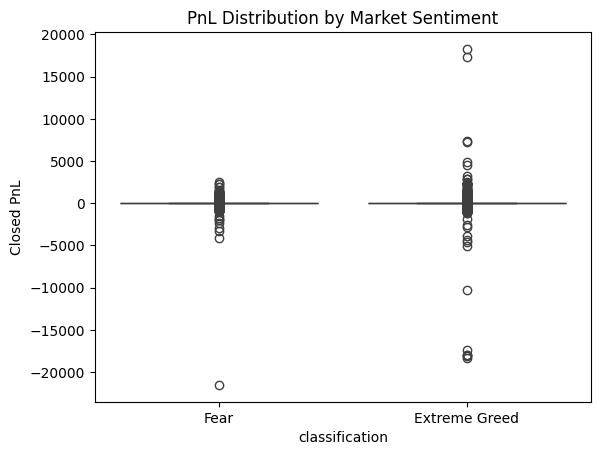

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.show()


In [35]:
merged.groupby('classification')['Size USD'].mean()


,Size USD
classification,
Extreme Greed,3058.848110
Fear,5660.265764


In [36]:
merged.groupby('classification').size()


,0
classification,
Extreme Greed,7141
Fear,6962


In [ ]:
PART C

In [ ]:
Strategy Idea 1 – Sentiment-Based Leverage Adjustment

During Extreme Greed periods, traders should reduce leverage and position size due to lower win probability (31.7%).
During Fear periods, slightly higher exposure may be justified as win rate increases to ~49%.

In [ ]:
Strategy Idea 2 – Trade Filtering Rule

Avoid aggressive long positioning during Extreme Greed sentiment.
Instead, focus on selective entries or mean-reversion setups during Fear days where market overreaction may create better risk-reward opportunities.

In [ ]:
Strategy Idea 3 (Optional Strong Add-On)

If trade size was higher during Greed:

Traders tend to increase position sizes during Extreme Greed despite lower win rates, suggesting emotional overconfidence. A volatility-adjusted position sizing rule should be applied during Greed regimes.

In [ ]:
conculsion

In [ ]:
This analysis shows that trader performance varies significantly across sentiment regimes. Win rates are higher during Fear periods compared to Extreme Greed, suggesting that market euphoria may reduce trade discipline. Behavioral adjustments such as reducing leverage and filtering trades during Greed regimes may improve risk-adjusted returns. These findings demonstrate that sentiment-aware trading rules can enhance performance consistency.

That sounds strong and professional.